We want to identify the dark and bright states associated with electromagnetic induced transparency (EIT) in our 3 level system where the field coupling the $|1\rangle\leftrightarrow|2\rangle$ transition is treated quantum mechanically.  This should be doable by looking at the eigenvalues and eigenvectors of the Hamiltonian.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg, optimize
import qutip as qu
import sympy as sym

In [2]:
# Set font size of plot elements\n",
SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 18
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

In [3]:
# Define our symbols
ωc, Ω10, Ω21, n, Δ, δ = sym.symbols("ω_c, Ω_10, Ω_21, n, Δ, δ")

In [4]:
# Define the Hamiltonian matrix in the fixed excitation basis: {|2, n-1>, |1, n>, |0, n>}
# Note that I've defined |0, n> = (1, 0, 0)^T so the term corresponding to the atomic ground state is in the upper left corner
H = sym.Matrix([[ωc * n, Ω10, 0],
                [Ω10, ωc * n - Δ, Ω21],
                [0, Ω21, ωc * n - δ - Δ]])
H

Matrix([
[n*ω_c,      Ω_10,             0],
[ Ω_10, n*ω_c - Δ,          Ω_21],
[    0,      Ω_21, n*ω_c - Δ - δ]])

In [5]:
# Set the detunings are 0 and remove ωc. H is then
temp = H.subs([(n, 0), (Δ, 0)])
temp

Matrix([
[   0, Ω_10,    0],
[Ω_10,    0, Ω_21],
[   0, Ω_21,   -δ]])

In [6]:
# Now calculate the eigenvectors and eigenvalues
eigs = temp.eigenvects()

# Print the first
print(eigs[0][0])
eigs[0][2][0]

-δ/3 - (3*Ω_10**2 + 3*Ω_21**2 + δ**2)/(3*(-27*Ω_10**2*δ/2 + δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2)/2 + sqrt(-4*(3*Ω_10**2 + 3*Ω_21**2 + δ**2)**3 + (-27*Ω_10**2*δ + 2*δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2))**2)/2)**(1/3)) - (-27*Ω_10**2*δ/2 + δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2)/2 + sqrt(-4*(3*Ω_10**2 + 3*Ω_21**2 + δ**2)**3 + (-27*Ω_10**2*δ + 2*δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2))**2)/2)**(1/3)/3


Matrix([
[-Ω_21/Ω_10 + δ*(-δ/3 - (3*Ω_10**2 + 3*Ω_21**2 + δ**2)/(3*(-27*Ω_10**2*δ/2 + δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2)/2 + sqrt(-4*(3*Ω_10**2 + 3*Ω_21**2 + δ**2)**3 + (-27*Ω_10**2*δ + 2*δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2))**2)/2)**(1/3)) - (-27*Ω_10**2*δ/2 + δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2)/2 + sqrt(-4*(3*Ω_10**2 + 3*Ω_21**2 + δ**2)**3 + (-27*Ω_10**2*δ + 2*δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2))**2)/2)**(1/3)/3)/(Ω_10*Ω_21) + (-δ/3 - (3*Ω_10**2 + 3*Ω_21**2 + δ**2)/(3*(-27*Ω_10**2*δ/2 + δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2)/2 + sqrt(-4*(3*Ω_10**2 + 3*Ω_21**2 + δ**2)**3 + (-27*Ω_10**2*δ + 2*δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2))**2)/2)**(1/3)) - (-27*Ω_10**2*δ/2 + δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2)/2 + sqrt(-4*(3*Ω_10**2 + 3*Ω_21**2 + δ**2)**3 + (-27*Ω_10**2*δ + 2*δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2))**2)/2)**(1/3)/3)**2/(Ω_10*Ω_21)],
[                                                                                                                                                                                           

In [7]:
# Second
print(eigs[1][0])
eigs[1][2][0]

-δ/3 - (3*Ω_10**2 + 3*Ω_21**2 + δ**2)/(3*(-1/2 - sqrt(3)*I/2)*(-27*Ω_10**2*δ/2 + δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2)/2 + sqrt(-4*(3*Ω_10**2 + 3*Ω_21**2 + δ**2)**3 + (-27*Ω_10**2*δ + 2*δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2))**2)/2)**(1/3)) - (-1/2 - sqrt(3)*I/2)*(-27*Ω_10**2*δ/2 + δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2)/2 + sqrt(-4*(3*Ω_10**2 + 3*Ω_21**2 + δ**2)**3 + (-27*Ω_10**2*δ + 2*δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2))**2)/2)**(1/3)/3


Matrix([
[-Ω_21/Ω_10 + δ*(-δ/3 - (3*Ω_10**2 + 3*Ω_21**2 + δ**2)/(3*(-1/2 - sqrt(3)*I/2)*(-27*Ω_10**2*δ/2 + δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2)/2 + sqrt(-4*(3*Ω_10**2 + 3*Ω_21**2 + δ**2)**3 + (-27*Ω_10**2*δ + 2*δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2))**2)/2)**(1/3)) - (-1/2 - sqrt(3)*I/2)*(-27*Ω_10**2*δ/2 + δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2)/2 + sqrt(-4*(3*Ω_10**2 + 3*Ω_21**2 + δ**2)**3 + (-27*Ω_10**2*δ + 2*δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2))**2)/2)**(1/3)/3)/(Ω_10*Ω_21) + (-δ/3 - (3*Ω_10**2 + 3*Ω_21**2 + δ**2)/(3*(-1/2 - sqrt(3)*I/2)*(-27*Ω_10**2*δ/2 + δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2)/2 + sqrt(-4*(3*Ω_10**2 + 3*Ω_21**2 + δ**2)**3 + (-27*Ω_10**2*δ + 2*δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2))**2)/2)**(1/3)) - (-1/2 - sqrt(3)*I/2)*(-27*Ω_10**2*δ/2 + δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2)/2 + sqrt(-4*(3*Ω_10**2 + 3*Ω_21**2 + δ**2)**3 + (-27*Ω_10**2*δ + 2*δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2))**2)/2)**(1/3)/3)**2/(Ω_10*Ω_21)],
[                                                                                                       

In [8]:
# Third
print(eigs[2][0])
eigs[2][2][0]

-δ/3 - (3*Ω_10**2 + 3*Ω_21**2 + δ**2)/(3*(-1/2 + sqrt(3)*I/2)*(-27*Ω_10**2*δ/2 + δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2)/2 + sqrt(-4*(3*Ω_10**2 + 3*Ω_21**2 + δ**2)**3 + (-27*Ω_10**2*δ + 2*δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2))**2)/2)**(1/3)) - (-1/2 + sqrt(3)*I/2)*(-27*Ω_10**2*δ/2 + δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2)/2 + sqrt(-4*(3*Ω_10**2 + 3*Ω_21**2 + δ**2)**3 + (-27*Ω_10**2*δ + 2*δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2))**2)/2)**(1/3)/3


Matrix([
[-Ω_21/Ω_10 + δ*(-δ/3 - (3*Ω_10**2 + 3*Ω_21**2 + δ**2)/(3*(-1/2 + sqrt(3)*I/2)*(-27*Ω_10**2*δ/2 + δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2)/2 + sqrt(-4*(3*Ω_10**2 + 3*Ω_21**2 + δ**2)**3 + (-27*Ω_10**2*δ + 2*δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2))**2)/2)**(1/3)) - (-1/2 + sqrt(3)*I/2)*(-27*Ω_10**2*δ/2 + δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2)/2 + sqrt(-4*(3*Ω_10**2 + 3*Ω_21**2 + δ**2)**3 + (-27*Ω_10**2*δ + 2*δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2))**2)/2)**(1/3)/3)/(Ω_10*Ω_21) + (-δ/3 - (3*Ω_10**2 + 3*Ω_21**2 + δ**2)/(3*(-1/2 + sqrt(3)*I/2)*(-27*Ω_10**2*δ/2 + δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2)/2 + sqrt(-4*(3*Ω_10**2 + 3*Ω_21**2 + δ**2)**3 + (-27*Ω_10**2*δ + 2*δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2))**2)/2)**(1/3)) - (-1/2 + sqrt(3)*I/2)*(-27*Ω_10**2*δ/2 + δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2)/2 + sqrt(-4*(3*Ω_10**2 + 3*Ω_21**2 + δ**2)**3 + (-27*Ω_10**2*δ + 2*δ**3 - 9*δ*(-Ω_10**2 - Ω_21**2))**2)/2)**(1/3)/3)**2/(Ω_10*Ω_21)],
[                                                                                                       

So the dark state is $|D\rangle = -\frac{\Omega_{21}}{\Omega_{10}}|0,n\rangle + |2, n-1\rangle$.  And the bright state is just the orthogonal superposition and is therefore $|B\rangle=\frac{\Omega_{10}}{\Omega_{21}}|0, n\rangle + |2,n-1\rangle$.  Now what happens if we let the $n\omega_c$ back into the Hamiltonian?

In [9]:
temp = H.subs([(Δ, 0), (δ, 0)])
temp

Matrix([
[n*ω_c,  Ω_10,     0],
[ Ω_10, n*ω_c,  Ω_21],
[    0,  Ω_21, n*ω_c]])

In [10]:
# Now calculate the eigenvectors and eigenvalues
eigs = temp.eigenvects()

# Print the first
print(eigs[0][0])
eigs[0][2][0]

n*ω_c


Matrix([
[-Ω_21/Ω_10],
[         0],
[         1]])

In [11]:
# Second
print(eigs[1][0])
eigs[1][2][0]

n*ω_c - sqrt(Ω_10**2 + Ω_21**2)


Matrix([
[                                           Ω_10/Ω_21],
[-n*ω_c/Ω_21 + (n*ω_c - sqrt(Ω_10**2 + Ω_21**2))/Ω_21],
[                                                   1]])

In [12]:
# Third
print(eigs[2][0])
eigs[2][2][0]

n*ω_c + sqrt(Ω_10**2 + Ω_21**2)


Matrix([
[                                           Ω_10/Ω_21],
[-n*ω_c/Ω_21 + (n*ω_c + sqrt(Ω_10**2 + Ω_21**2))/Ω_21],
[                                                   1]])

So while there is no eigenvalue of 0, that's because each eigenvalue received a constant boost of $n\omega_c$ as expected.  The eigenvalue that corresponds to 0 is just $n\omega_c$ and it turns out that the eigenvector (and therefore the dark state) doesn't change in this case.  This is also to be expected.  Adding a constant to the Hamiltonian shouldn't modify the eigenvectors.

In [13]:
p_00, p_01, p_02, p_10, p_11, p_12, p_20, p_21, p_22 = sym.symbols("p_00, p_01, p_02, p_10, p_11, p_12, p_20, p_21, p_22")
γ2, γ1, γ01, γ02, γ12, r21, r20, γ2d, γ1d = sym.symbols("γ_2, γ_1, γ_01, γ_02, γ_12, r_21, r_20, γ_2d, γ_1d")
κ, n = sym.symbols("κ, n")

In [14]:
p = sym.Matrix([[p_00, p_01, p_02],
                [p_10, p_11, p_12],
                [p_20, p_21, p_22]])
s01 = sym.Matrix([[0, 1, 0], [0, 0, 0], [0, 0, 0]])
s12 = sym.Matrix([[0, 0, 0], [0, 0, 1], [0, 0, 0]])
s11 = sym.Matrix([[0, 0, 0], [0, 1, 0], [0, 0, 0]])
s22 = sym.Matrix([[0, 0, 0], [0, 0, 0], [0, 0, 1]])

In [15]:
a = γ1 / 2 * (2 * s01 * p * s01.H - s11 * p - p * s11)
a

Matrix([
[   p_11*γ_1, -p_01*γ_1/2,           0],
[-p_10*γ_1/2,   -p_11*γ_1, -p_12*γ_1/2],
[          0, -p_21*γ_1/2,           0]])

In [16]:
b = γ2 / 2 * (2 * s12 * p * s12.H - s22 * p - p * s22)
b

Matrix([
[          0,           0, -p_02*γ_2/2],
[          0,    p_22*γ_2, -p_12*γ_2/2],
[-p_20*γ_2/2, -p_21*γ_2/2,   -p_22*γ_2]])

In [17]:
c = γ1d / 2 * (2 * s11 * p * s11.H - s11 * p - p * s11)
c

Matrix([
[           0, -p_01*γ_1d/2,            0],
[-p_10*γ_1d/2,            0, -p_12*γ_1d/2],
[           0, -p_21*γ_1d/2,            0]])

In [18]:
d = γ2d / 2 * (2 * s22 * p * s22.H - s22 * p - p * s22)
d

Matrix([
[           0,            0, -p_02*γ_2d/2],
[           0,            0, -p_12*γ_2d/2],
[-p_20*γ_2d/2, -p_21*γ_2d/2,            0]])

In [19]:
a + b + c + d

Matrix([
[                 p_11*γ_1,                            -p_01*γ_1/2 - p_01*γ_1d/2,                            -p_02*γ_2/2 - p_02*γ_2d/2],
[-p_10*γ_1/2 - p_10*γ_1d/2,                                 -p_11*γ_1 + p_22*γ_2, -p_12*γ_1/2 - p_12*γ_1d/2 - p_12*γ_2/2 - p_12*γ_2d/2],
[-p_20*γ_2/2 - p_20*γ_2d/2, -p_21*γ_1/2 - p_21*γ_1d/2 - p_21*γ_2/2 - p_21*γ_2d/2,                                            -p_22*γ_2]])

In [20]:
ann = sym.Matrix([[n, 0, 0], [0, n, 0], [0, 0, n-1]])
p_c = sym.Matrix([[p_00, p_01], [p_10, p_11]])
e = κ / 2 * (-ann * p - p * ann)
e

Matrix([
[                   -n*p_00*κ,                    -n*p_01*κ,      κ*(-n*p_02 - p_02*(n - 1))/2],
[                   -n*p_10*κ,                    -n*p_11*κ,      κ*(-n*p_12 - p_12*(n - 1))/2],
[κ*(-n*p_20 + p_20*(1 - n))/2, κ*(-n*p_21 + p_21*(1 - n))/2, κ*(p_22*(1 - n) - p_22*(n - 1))/2]])

In [21]:
p * s22 + s22 * p

Matrix([
[   0,    0,   p_02],
[   0,    0,   p_12],
[p_20, p_21, 2*p_22]])

Let's try and recreate fig 1c from the Ningyuan paper that Kevin sent over.

In [22]:
δl = np.linspace(-25, 25, 100) # detuning parameter in MHz
g21 = 13 / 2  # cavity coupling strength in MHz
g10 = 7 / 2   # probe coupling strength in MHz
κ = 1.5
γ21 = 1
γ10 = 1

In [23]:
Ts = np.zeros(δl.shape[0], dtype=complex)
for i in range(δl.shape[0]):
    Hi = np.array([[δl[i] + 1j * κ, g10, 0],
                   [g10, δl[i] + 1j * γ10, g21],
                   [0, g21, δl[i] + 1j * γ21]], dtype=complex)
    Ts[i] = np.abs(np.array([1, 0, 0]).conj().T @ np.linalg.inv(Hi) @ np.array([1, 0, 0])) ** 2

/home/jacob/anaconda3/envs/mode_cooling/lib/python3.11/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/jacob/anaconda3/envs/mode_cooling/lib/python3.11/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


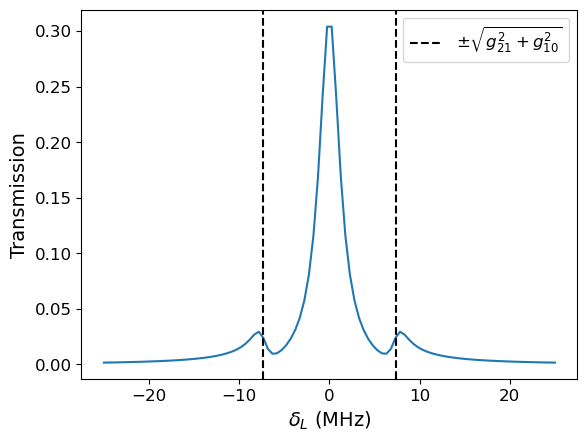

In [24]:
plt.plot(δl, Ts)
plt.xlabel("$\\delta_L$ (MHz)")
plt.ylabel("Transmission")
plt.axvline(x=-np.sqrt(g21 ** 2 + g10 ** 2), linestyle='--', color='k', label='$\\pm\\sqrt{g_{21}^2 + g_{10}^2}$')
plt.axvline(x=np.sqrt(g21 ** 2 + g10 ** 2), linestyle='--', color='k')
plt.legend()
plt.savefig("transmission_vs_delta_L.png", format='png', dpi=300)

## 4 Level

In [25]:
# We'll redefine our symbols to make sure there's no confusion
ωc, g10, g21, g32, n, δ, Δ1, Δ2 = sym.symbols("ω_c, g_10, g_21, g_32, n, δ, Δ1, Δ2")

In [26]:
# Define the Hamiltonian
H = sym.Matrix([[n * ωc, g10, 0, 0],
                [g10, n * ωc - Δ1, g21, 0],
                [0, g21, n * ωc - Δ1 - Δ2, g32],
                [0, 0, g32, n * ωc - δ - Δ1 - Δ2]])
H

Matrix([
[n*ω_c,       g_10,               0,                   0],
[ g_10, n*ω_c - Δ1,            g_21,                   0],
[    0,       g_21, n*ω_c - Δ1 - Δ2,                g_32],
[    0,          0,            g_32, n*ω_c - Δ1 - Δ2 - δ]])

In [27]:
# Set the detunings to zero and calculate the eigenvectors and eigenvalues
temp = H.subs([(n, 0), (δ, 0), (Δ1, 0), (Δ2, 0)])
print(temp)
eigs = temp.eigenvects()

Matrix([[0, g_10, 0, 0], [g_10, 0, g_21, 0], [0, g_21, 0, g_32], [0, 0, g_32, 0]])


In [28]:
eigs[3][0]

sqrt(g_10**2/2 + g_21**2/2 + g_32**2/2 + sqrt(g_10**4 + 2*g_10**2*g_21**2 - 2*g_10**2*g_32**2 + g_21**4 + 2*g_21**2*g_32**2 + g_32**4)/2)

In [29]:
# first eigenvalue and eigvenvector
print("First eigenvalue: ", eigs[0][0])
eigs[0][2][0]

First eigenvalue:  -sqrt(g_10**2/2 + g_21**2/2 + g_32**2/2 - sqrt(g_10**4 + 2*g_10**2*g_21**2 - 2*g_10**2*g_32**2 + g_21**4 + 2*g_21**2*g_32**2 + g_32**4)/2)


Matrix([
[-(-g_21**2 - g_32**2)*sqrt(g_10**2/2 + g_21**2/2 + g_32**2/2 - sqrt(g_10**4 + 2*g_10**2*g_21**2 - 2*g_10**2*g_32**2 + g_21**4 + 2*g_21**2*g_32**2 + g_32**4)/2)/(g_10*g_21*g_32) - (g_10**2/2 + g_21**2/2 + g_32**2/2 - sqrt(g_10**4 + 2*g_10**2*g_21**2 - 2*g_10**2*g_32**2 + g_21**4 + 2*g_21**2*g_32**2 + g_32**4)/2)**(3/2)/(g_10*g_21*g_32)],
[                                                                                                                                                                                  -g_32/g_21 + (g_10**2/2 + g_21**2/2 + g_32**2/2 - sqrt(g_10**4 + 2*g_10**2*g_21**2 - 2*g_10**2*g_32**2 + g_21**4 + 2*g_21**2*g_32**2 + g_32**4)/2)/(g_21*g_32)],
[                                                                                                                                                                                                 -sqrt(g_10**2/2 + g_21**2/2 + g_32**2/2 - sqrt(g_10**4 + 2*g_10**2*g_21**2 - 2*g_10**2*g_32**2 + g_21**4 + 2*g_21**2*

In [30]:
# second
print("Second eigenvalue: ", eigs[1][0])
eigs[1][2][0]

Second eigenvalue:  sqrt(g_10**2/2 + g_21**2/2 + g_32**2/2 - sqrt(g_10**4 + 2*g_10**2*g_21**2 - 2*g_10**2*g_32**2 + g_21**4 + 2*g_21**2*g_32**2 + g_32**4)/2)


Matrix([
[(-g_21**2 - g_32**2)*sqrt(g_10**2/2 + g_21**2/2 + g_32**2/2 - sqrt(g_10**4 + 2*g_10**2*g_21**2 - 2*g_10**2*g_32**2 + g_21**4 + 2*g_21**2*g_32**2 + g_32**4)/2)/(g_10*g_21*g_32) + (g_10**2/2 + g_21**2/2 + g_32**2/2 - sqrt(g_10**4 + 2*g_10**2*g_21**2 - 2*g_10**2*g_32**2 + g_21**4 + 2*g_21**2*g_32**2 + g_32**4)/2)**(3/2)/(g_10*g_21*g_32)],
[                                                                                                                                                                                 -g_32/g_21 + (g_10**2/2 + g_21**2/2 + g_32**2/2 - sqrt(g_10**4 + 2*g_10**2*g_21**2 - 2*g_10**2*g_32**2 + g_21**4 + 2*g_21**2*g_32**2 + g_32**4)/2)/(g_21*g_32)],
[                                                                                                                                                                                                 sqrt(g_10**2/2 + g_21**2/2 + g_32**2/2 - sqrt(g_10**4 + 2*g_10**2*g_21**2 - 2*g_10**2*g_32**2 + g_21**4 + 2*g_21**2*g_3

In [31]:
# third
print("Third eigenvalue: ", eigs[2][0])
eigs[2][2][0]

Third eigenvalue:  -sqrt(g_10**2/2 + g_21**2/2 + g_32**2/2 + sqrt(g_10**4 + 2*g_10**2*g_21**2 - 2*g_10**2*g_32**2 + g_21**4 + 2*g_21**2*g_32**2 + g_32**4)/2)


Matrix([
[-(-g_21**2 - g_32**2)*sqrt(g_10**2/2 + g_21**2/2 + g_32**2/2 + sqrt(g_10**4 + 2*g_10**2*g_21**2 - 2*g_10**2*g_32**2 + g_21**4 + 2*g_21**2*g_32**2 + g_32**4)/2)/(g_10*g_21*g_32) - (g_10**2/2 + g_21**2/2 + g_32**2/2 + sqrt(g_10**4 + 2*g_10**2*g_21**2 - 2*g_10**2*g_32**2 + g_21**4 + 2*g_21**2*g_32**2 + g_32**4)/2)**(3/2)/(g_10*g_21*g_32)],
[                                                                                                                                                                                  -g_32/g_21 + (g_10**2/2 + g_21**2/2 + g_32**2/2 + sqrt(g_10**4 + 2*g_10**2*g_21**2 - 2*g_10**2*g_32**2 + g_21**4 + 2*g_21**2*g_32**2 + g_32**4)/2)/(g_21*g_32)],
[                                                                                                                                                                                                 -sqrt(g_10**2/2 + g_21**2/2 + g_32**2/2 + sqrt(g_10**4 + 2*g_10**2*g_21**2 - 2*g_10**2*g_32**2 + g_21**4 + 2*g_21**2*

In [32]:
# fourth
print("Fourth eigenvalue: ", eigs[3][0])
eigs[3][2][0]

Fourth eigenvalue:  sqrt(g_10**2/2 + g_21**2/2 + g_32**2/2 + sqrt(g_10**4 + 2*g_10**2*g_21**2 - 2*g_10**2*g_32**2 + g_21**4 + 2*g_21**2*g_32**2 + g_32**4)/2)


Matrix([
[(-g_21**2 - g_32**2)*sqrt(g_10**2/2 + g_21**2/2 + g_32**2/2 + sqrt(g_10**4 + 2*g_10**2*g_21**2 - 2*g_10**2*g_32**2 + g_21**4 + 2*g_21**2*g_32**2 + g_32**4)/2)/(g_10*g_21*g_32) + (g_10**2/2 + g_21**2/2 + g_32**2/2 + sqrt(g_10**4 + 2*g_10**2*g_21**2 - 2*g_10**2*g_32**2 + g_21**4 + 2*g_21**2*g_32**2 + g_32**4)/2)**(3/2)/(g_10*g_21*g_32)],
[                                                                                                                                                                                 -g_32/g_21 + (g_10**2/2 + g_21**2/2 + g_32**2/2 + sqrt(g_10**4 + 2*g_10**2*g_21**2 - 2*g_10**2*g_32**2 + g_21**4 + 2*g_21**2*g_32**2 + g_32**4)/2)/(g_21*g_32)],
[                                                                                                                                                                                                 sqrt(g_10**2/2 + g_21**2/2 + g_32**2/2 + sqrt(g_10**4 + 2*g_10**2*g_21**2 - 2*g_10**2*g_32**2 + g_21**4 + 2*g_21**2*g_3

So it seems that there isn't a dark state in that none of the eigenvalues are 0 and the all of the eigenvector on all of the basis states.  I wonder if it's possible to show that that's the case from 3x3 case?

In [33]:
δl = np.linspace(-25, 25, 100) # detuning parameter in MHz
g32 = 0.1 / 2  # cavity coupling strength in MHz
g21 = 13 / 2  # probe 1 coupling strength in MHz
g10 = 7 / 2   # probe 2 coupling strength in MHz
κ = 2
γ32 = 0.1
γ21 = 0.1
γ10 = 0.1

In [34]:
λ1 = np.sqrt((g10 ** 2 + g21 ** 2 + g32 ** 2) / 2 - 0.5 * np.sqrt(g10 ** 4 + 2*g10**2*g21**2 - 2*g10**2*g32**2 + g21**4 + 2*g21**2*g32**2 + g32**4))
λ0 = -λ1
λ3 = np.sqrt((g10 ** 2 + g21 ** 2 + g32 ** 2) / 2 + 0.5 * np.sqrt(g10 ** 4 + 2*g10**2*g21**2 - 2*g10**2*g32**2 + g21**4 + 2*g21**2*g32**2 + g32**4))
λ2 = -λ3

In [35]:
Ts = np.zeros(δl.shape[0], dtype=complex)
for i in range(δl.shape[0]):
    Hi = np.array([[δl[i] + 1j * κ, g10, 0, 0],
                   [g10, δl[i] + 1j * γ10, g21, 0],
                   [0, g21, δl[i] + 1j * γ21, g32],
                   [0, 0, g32, δl[i] + 1j * γ32]], dtype=complex)
    Ts[i] = np.abs(np.array([1, 0, 0, 0]).conj().T @ np.linalg.inv(Hi) @ np.array([1, 0, 0, 0])) ** 2

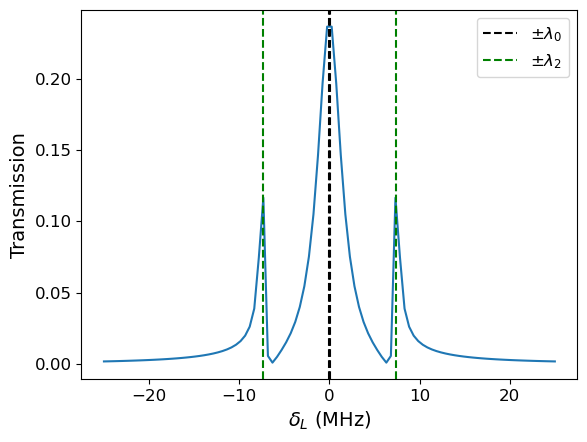

In [36]:
plt.plot(δl, Ts)
plt.xlabel("$\\delta_L$ (MHz)")
plt.ylabel("Transmission")
plt.axvline(x=λ0, linestyle='--', color='k', label='$\\pm\\lambda_0$')
plt.axvline(x=λ1, linestyle='--', color='k')
plt.axvline(x=λ2, linestyle='--', color='g', label='$\\pm\\lambda_2$')
plt.axvline(x=λ3, linestyle='--', color='g')
plt.legend()
plt.savefig("transmission_vs_delta_L_4lvl.png", format='png', dpi=300)

## 5 level
This isn't really useful, but I'm curious if the dark state will come back if we consider a 5 level system

In [37]:
g10, g21, g32, g43 = sym.symbols("g_10, g_21, g_32, g_43")

In [38]:
# Define the Hamiltonian
H = sym.Matrix([[0, g10, 0, 0, 0],
                [g10, 0, g21, 0, 0],
                [0, g21, 0, g32, 0],
                [0, 0, g32, 0, g43],
                [0, 0, 0, g43, 0]])
H

Matrix([
[   0, g_10,    0,    0,    0],
[g_10,    0, g_21,    0,    0],
[   0, g_21,    0, g_32,    0],
[   0,    0, g_32,    0, g_43],
[   0,    0,    0, g_43,    0]])

In [39]:
eigs = H.eigenvects()

In [40]:
eigs[0][0]

0

In [41]:
eigs[1][0]

-sqrt(g_10**2/2 + g_21**2/2 + g_32**2/2 + g_43**2/2 - sqrt(g_10**4 + 2*g_10**2*g_21**2 - 2*g_10**2*g_32**2 - 2*g_10**2*g_43**2 + g_21**4 + 2*g_21**2*g_32**2 - 2*g_21**2*g_43**2 + g_32**4 + 2*g_32**2*g_43**2 + g_43**4)/2)

In [42]:
eigs[2][0]

sqrt(g_10**2/2 + g_21**2/2 + g_32**2/2 + g_43**2/2 - sqrt(g_10**4 + 2*g_10**2*g_21**2 - 2*g_10**2*g_32**2 - 2*g_10**2*g_43**2 + g_21**4 + 2*g_21**2*g_32**2 - 2*g_21**2*g_43**2 + g_32**4 + 2*g_32**2*g_43**2 + g_43**4)/2)

In [43]:
eigs[3][0]

-sqrt(g_10**2/2 + g_21**2/2 + g_32**2/2 + g_43**2/2 + sqrt(g_10**4 + 2*g_10**2*g_21**2 - 2*g_10**2*g_32**2 - 2*g_10**2*g_43**2 + g_21**4 + 2*g_21**2*g_32**2 - 2*g_21**2*g_43**2 + g_32**4 + 2*g_32**2*g_43**2 + g_43**4)/2)

In [44]:
eigs[4][0]

sqrt(g_10**2/2 + g_21**2/2 + g_32**2/2 + g_43**2/2 + sqrt(g_10**4 + 2*g_10**2*g_21**2 - 2*g_10**2*g_32**2 - 2*g_10**2*g_43**2 + g_21**4 + 2*g_21**2*g_32**2 - 2*g_21**2*g_43**2 + g_32**4 + 2*g_32**2*g_43**2 + g_43**4)/2)

So there is a dark state in this case.  That's interesting.  Does it show up in the transmission spectrum if we do the same calculation?

In [45]:
δl = np.linspace(-25, 25, 100) # detuning parameter in MHz
g43 = 25 / 2
g32 = 19 / 2  # cavity coupling strength in MHz
g21 = 13 / 2  # probe 1 coupling strength in MHz
g10 = 7 / 2   # probe 2 coupling strength in MHz
κ = 2
γ43 = 0.01
γ32 = 0.01
γ21 = 0.01
γ10 = 0.01

In [46]:
Ts = np.zeros(δl.shape[0], dtype=complex)
for i in range(δl.shape[0]):
    Hi = np.array([[δl[i] + 1j * κ, g10, 0, 0, 0],
                   [g10, δl[i] + 1j * γ10, g21, 0, 0],
                   [0, g21, δl[i] + 1j * γ21, g32, 0],
                   [0, 0, g32, δl[i] + 1j * γ32, g43],
                   [0, 0, 0, g43, δl[i] + 1j * γ43]], dtype=complex)
    Ts[i] = np.abs(np.array([1, 0, 0, 0, 0]).conj().T @ np.linalg.inv(Hi) @ np.array([1, 0, 0, 0, 0])) ** 2

Text(0, 0.5, 'Transmission')

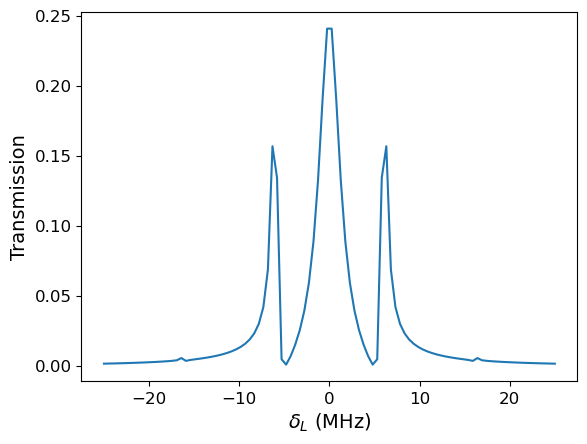

In [47]:
plt.plot(δl, Ts)
plt.xlabel("$\\delta_L$ (MHz)")
plt.ylabel("Transmission")

## Our system
It turns out that using this non-Hermitian perturbation theory approach with our system is not as straightforward as I thought at first.  From what I can tell, we should get something that is basically the same, but the bases we use to represent the Hamiltonian matrix are different.  In the Ningyuang paper, it appears that they use $|C\rangle = |1,0\rangle, |E\rangle = |0, 1\rangle, |R\rangle = |0, 2\rangle$ as their basis because the cavity couples the ground state of the atom to the first excited state.  In our case, we would have $|1, 0\rangle, |1, 1\rangle, |0, 2\rangle$ as our basis.  If we think about defining these as $|G\rangle, |C\rangle, |R\rangle$ in analogy to the Ningyuang paper, we can rewrite the Hamiltonian to match the Ningyuang paper $H_0 = -i\gamma_G|G\rangle\langle G| - (\Delta + i\kappa)|C\rangle\langle C| - (\Delta + \delta + i\gamma_R)|R\rangle\langle R| + g_{21}(|R\rangle\langle C| + |C\rangle\langle R|) + g_{10}(|C\rangle\langle G| + |G\langle\rangle C|)$.

In [70]:
# Create symbols for Hamiltonian matrix in G, C, R basis
γ1, Δ, κ, δ, γ2, g21, g10 = sym.symbols("γ_1, Δ, κ, δ, γ_2, g_21, g_10")

# Create Hamiltonian
H = sym.Matrix([[0, g10, 0],
                [g10, 1j*γ1, g10],
                [0, g10, 1j*γ2]])
H

Matrix([
[   0,      g_10,         0],
[g_10, 1.0*I*γ_1,      g_10],
[   0,      g_10, 1.0*I*γ_2]])

In [77]:
type(eigs[0][0])

sympy.core.add.Add

In [79]:
eigs = H.eigenvects()
sym.simplify(eigs[0][0].subs([(γ1, 0), (γ2, 0)]))

(-0.816496580927726*g_10**2 - 0.816496580927726*(-g_10**6)**0.333333333333333)/(-g_10**6)**0.166666666666667

In [80]:
sym.simplify(eigs[1][0].subs([(γ1, 0), (γ2, 0)]))

(g_10**2*(0.408248290463863 - 0.707106781186548*I) + (-g_10**6)**0.333333333333333*(0.408248290463863 + 0.707106781186547*I))/(-g_10**6)**0.166666666666667

In [73]:
sym.simplify(eigs[2])

(0.333333333333333*I*γ_1 + 0.333333333333333*I*γ_2 + 0.408248290463863*(0.166666666666667 + 0.288675134594813*I)*(6.0*g_10**2 + 3.0*γ_1*γ_2 + (-I*γ_1 - I*γ_2)**2)/(0.918558653543692*I*g_10**2*γ_2 - 0.0340206908719886*(-2.0*g_10**2 - γ_1*γ_2)*(-9.0*I*γ_1 - 9.0*I*γ_2) + 0.0680413817439772*(-I*γ_1 - I*γ_2)**3 + (-(g_10**2 + 0.5*γ_1*γ_2 + 0.166666666666667*(-I*γ_1 - I*γ_2)**2)**3 + 0.84375*(I*g_10**2*γ_2 - 0.037037037037037*(-2.0*g_10**2 - γ_1*γ_2)*(-9.0*I*γ_1 - 9.0*I*γ_2) + 0.0740740740740741*(-I*γ_1 - I*γ_2)**3)**2)**0.5)**0.333333333333333 + 2.44948974278318*(0.166666666666667 - 0.288675134594813*I)*(0.918558653543692*I*g_10**2*γ_2 - 0.0340206908719886*(-2.0*g_10**2 - γ_1*γ_2)*(-9.0*I*γ_1 - 9.0*I*γ_2) + 0.0680413817439772*(-I*γ_1 - I*γ_2)**3 + (-(g_10**2 + 0.5*γ_1*γ_2 + 0.166666666666667*(-I*γ_1 - I*γ_2)**2)**3 + 0.84375*(I*g_10**2*γ_2 - 0.037037037037037*(-2.0*g_10**2 - γ_1*γ_2)*(-9.0*I*γ_1 - 9.0*I*γ_2) + 0.0740740740740741*(-I*γ_1 - I*γ_2)**3)**2)**0.5)**0.333333333333333, 1, [Matrix(

Note that if we set the detunings and decay rates to 0, we'll get the same eigenvalues as the 3 level case before, which seems promising.  Now we'll just give numerical values and proceed with the perturbation theory result to get the transmission.

In [49]:
# Define the parameters
δl = np.linspace(-25, 25, 100) # detuning parameter in MHz
g21 = 13 / 2  # cavity coupling strength in MHz
g10 = 7 / 2   # probe coupling strength in MHz
κ = 1.5
γG = 1
γR = 1

# Define the Hamiltonian numerically
H1 = np.array([[0, g10, 0],
               [g10, -1j * κ - 1j * γG, g21],
               [0, g21, -1j * γR]], dtype=complex)

In [50]:
# Calculate the transmission spectrum
Ts = np.zeros(δl.shape[0])
for i in range(δl.shape[0]):
    Ts[i] = np.abs(np.array([1, 0, 0]).conj().T @ np.linalg.inv(δl[i] * np.eye(3) - H1) @ np.array([1, 0, 0])) ** 2

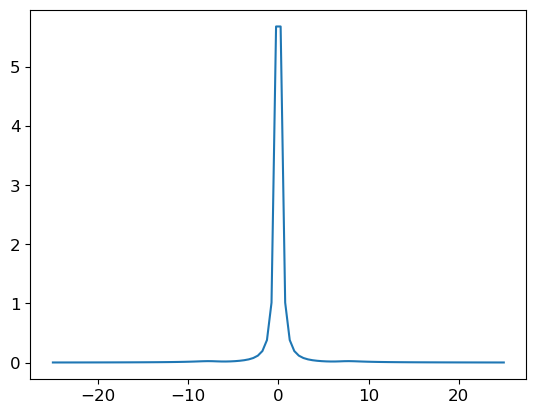

In [51]:
plt.plot(δl, Ts.real)